In [ ]:
print("HELLO WORLD")
print("HELLO WORLD")

HELLO WORLD


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory, folx_hamiltonian
from complex_vmc import c_wavefunctions, c_trajectory, c_folx_hamiltonian, c_optimization

import importlib

In [3]:
jax.config.update("jax_enable_x64", True)

In [4]:
N = 14
r_ws = 10.0
walkers = 16
dim = 3
numKpoints = N

spins = (N//2,N-N//2)
lattice = wavefunctions.computeLattice(N, r_ws, dim)
kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)[:spins[0]]

rng = jax.random.PRNGKey(558)
rng, rs_rng, init_rng = jax.random.split(rng, 3)

centers = trajectory.generateBCC(spins, lattice, dim)
(upCenters,downCenters) = centers[:spins[0]], centers[spins[0]:]
rs = centers[None,:,:] + (r_ws / 10) * jax.random.normal(rs_rng, shape=(walkers,N,dim))

wavefunction = wavefunctions.LogSimpleSlaters(spins, dim, kpoints)
wavefunction = wavefunctions.LogSlaterCYJastrow(spins, dim, lattice, kpoints)
mala = trajectory.MALAUpdater(wavefunction, r_ws)
kinetic_energy = folx_hamiltonian.LocalKineticEnergy(wavefunction, 6)

parameters = wavefunction.initBatch(init_rng, rs)

logmags = wavefunction.applyBatch(parameters, rs)
newRs = mala.updateBatch(parameters, rs, rng, 1e-1)
kes = kinetic_energy.batch(parameters, rs)

ref_ke = jnp.sum(jnp.square(kpoints))

print(logmags.shape)
print(newRs.shape)
print(kes.shape)
print()

print(ref_ke)
print(kes)

(16,)
(16, 14, 3)
(16,)

0.15692780148560848
[1.45828114 1.73804371 2.18244267 1.94173111 1.93791003 1.75552926
 2.22695446 1.95698646 1.74126278 2.02101617 3.99961197 3.22517035
 2.0999522  1.23008572 2.08478441 2.72808987]


In [5]:
importlib.reload(c_wavefunctions)
importlib.reload(c_trajectory)
importlib.reload(c_folx_hamiltonian)
importlib.reload(c_optimization)

N = 14
r_ws = 10.0
walkers = 16
dim = 3
numKpoints = N

spins = (N//2,N-N//2)
lattice = c_wavefunctions.computeLattice(N, r_ws, dim)
kpoints = c_wavefunctions.genKpoints(numKpoints, lattice, dim)[:spins[0]]

rng = jax.random.PRNGKey(558)
rng, rs_rng, init_rng = jax.random.split(rng, 3)

centers = c_trajectory.generateBCC(spins, lattice, dim)
(upCenters,downCenters) = centers[:spins[0]], centers[spins[0]:]
rs = centers[None,:,:] + (r_ws / 10) * jax.random.normal(rs_rng, shape=(walkers,N,dim))

#wavefunction = c_wavefunctions.LogSimpleSlaters(spins, dim, kpoints)
wavefunction = c_wavefunctions.LogSlaterCYJastrow(spins, dim, lattice, kpoints)
mala = c_trajectory.MALAUpdater(wavefunction, r_ws)
energy = c_folx_hamiltonian.LocalEnergyUEG3D(wavefunction, lattice, 6)
optimizer = c_optimization.StochasticReconfigurationMomentum(wavefunction, energy)

parameters = wavefunction.initBatch(init_rng, rs)

phases, logmags = wavefunction.applyBatch(parameters, rs)
newRs = mala.updateBatch(parameters, rs, rng, 1e-1)
energies = energy.batch(parameters, rs)

ref_ke = jnp.sum(jnp.square(kpoints))

print(phases.shape, logmags.shape)
print(phases.dtype, logmags.dtype)
print(newRs.shape)
print(energies.shape)
print()

print(parameters)

optimizer(parameters, rs, 1e-2, 1e-3, 0.0, 0.0)

(16,) (16,)
float64 float64
(16, 14, 3)
(16,)

{'params': {'CYJastrow': {'As_same_diff': Array([18.25741858, 18.25741858], dtype=float64)}}}


(Array(True, dtype=bool),
 Array([0.30558872+7.84123701e-17j, 0.58920677-4.18221061e-16j,
        1.00245507-2.61648092e-16j, 0.76173276+4.07842451e-16j,
        0.74079007+3.48458000e-16j, 0.57047865-1.71421943e-16j,
        1.01458335+1.25045098e-16j, 0.77901044+1.04796346e-16j,
        0.56869332-1.61644111e-16j, 0.8384524 +2.13062918e-16j,
        2.81347099-4.56834329e-14j, 2.0445247 +2.20902331e-15j,
        0.90433893+2.36605034e-16j, 0.03378637+1.92015998e-15j,
        0.90657755-1.13737150e-15j, 1.5305992 -1.38499969e-16j],      dtype=complex128),
 {'params': {'CYJastrow': {'As_same_diff': Array([18.25569537, 18.24756818], dtype=float64)}}},
 Array([-0.1723217 , -0.98504073], dtype=float64))

complex128 (169, 28)
complex128 (169, 28)


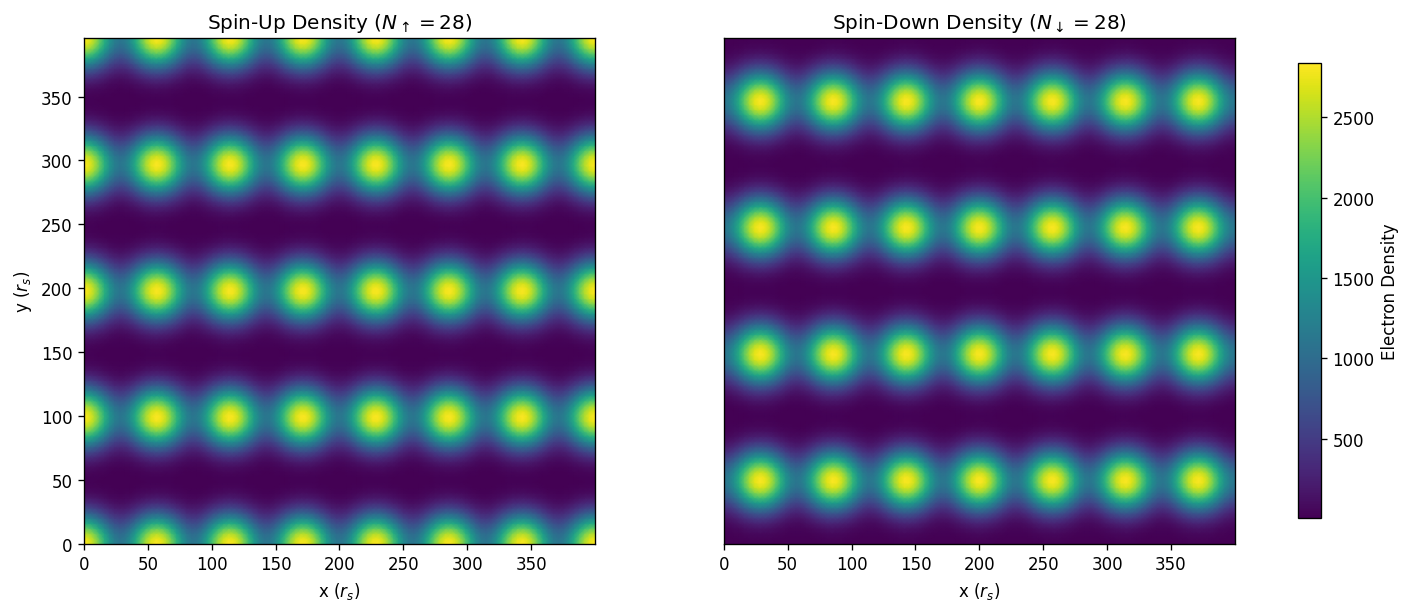

In [12]:
importlib.reload(c_wavefunctions)

r_ws = 30

N = 56
dim = 2
numKpts = 169

NUp = N // 2
NDown = N - NUp
spins = ( NUp , NDown )

lattice = c_wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)
rec_lattice = jnp.linalg.inv(lattice)
kpoints = c_wavefunctions.genKpoints(numKpts, lattice, dim)
    
centers = trajectory.generateStripedAFM(spins, lattice, dim, gridShape=(7,4))
(upCenters,downCenters) = centers[:spins[0]], centers[spins[0]:]
rs = centers[None,:,:] + (r_ws / 10) * jax.random.normal(rs_rng, shape=(walkers,N,dim))

alpha = 1 / (r_ws ** 2.0)

upCoeffs = c_wavefunctions.generateGaussianMPCoeffs(kpoints, upCenters, alpha)
downCoeffs = c_wavefunctions.generateGaussianMPCoeffs(kpoints, downCenters, alpha)

print(upCoeffs.dtype, upCoeffs.shape)
print(downCoeffs.dtype, downCoeffs.shape)

def eval_basis_at_point(r):
    return jnp.exp(1j * jnp.dot(kpoints, r))

# 3. Generate Grid
n_grid = 100
u = jnp.linspace(0, 1, n_grid)
v = jnp.linspace(0, 1, n_grid)
uu, vv = jnp.meshgrid(u, v) 
flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
flat_real = flat_frac @ lattice 

# 4. Compute Densities
# Evaluate basis: (N_grid, N_k)
basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 

# Calculate Up Orbitals: (N_grid, N_k) @ (N_k, N_up) -> (N_grid, N_up)
orbitals_up = jnp.dot(basis_vals, upCoeffs)
# Calculate Down Orbitals: (N_grid, N_k) @ (N_k, N_down) -> (N_grid, N_down)
orbitals_down = jnp.dot(basis_vals, downCoeffs)

# Sum squares to get density
rho_up = jnp.sum(jnp.abs(orbitals_up)**2, axis=1).reshape(n_grid, n_grid)
rho_down = jnp.sum(jnp.abs(orbitals_down)**2, axis=1).reshape(n_grid, n_grid)

# 5. Plot Side-by-Side
# Grid coordinates for plotting
grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
X_plot = grid_real[:, :, 0]
Y_plot = grid_real[:, :, 1]

# Determine global min/max for shared colorbar
vmin = min(rho_up.min(), rho_down.min())
vmax = max(rho_up.max(), rho_down.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)

# Plot Up
im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f"Spin-Up Density ($N_{{\\uparrow}}={NUp}$)")
axes[0].set_aspect('equal')
axes[0].set_xlabel("x ($r_s$)")
axes[0].set_ylabel("y ($r_s$)")

# Plot Down
im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f"Spin-Down Density ($N_{{\\downarrow}}={NDown}$)")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x ($r_s$)")
axes[1].set_yticks([]) # Hide Y ticks for the second plot

# Shared Colorbar
fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)
plt.show()

In [16]:
print(jnp.real(upCoeffs).dtype)
print(jnp.imag(upCoeffs).dtype)

float64
float64
